In [118]:

import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing

In [119]:
# Depickle
pickle_in = open("data/train.pkl", "rb")
result = pickle.load(pickle_in)

In [120]:
# Convert to numpy array and display the first 5 elements
train_set_full = np.array(result)
train_set_full[:5]

array([[ 2.74276567e+01,  3.33578295e+03],
       [-4.96183456e+00,  2.64740265e+03],
       [-2.78611955e+01,  5.20733695e+02],
       [-1.53463398e+01,  3.51892491e+03],
       [ 2.86732690e+00, -3.21770068e+03]])

In [121]:
# Shuffle the dataset
np.random.shuffle(train_set_full)
train_set_full

array([[ 3.01786808e+01,  7.54415822e+03],
       [-2.44568968e+01, -4.81681508e+02],
       [ 8.08527264e+00,  5.89795207e+02],
       ...,
       [ 7.44689452e+00,  1.21802878e+03],
       [-3.41631584e+01, -2.85462512e+03],
       [ 1.28234343e+01, -4.06041547e+03]])

In [122]:
# Separate the dataset
num_datasets = 16
train_sets = np.split(train_set_full, num_datasets)
train_sets[0][:3]

array([[  30.17868084, 7544.15821674],
       [ -24.45689675, -481.68150829],
       [   8.08527264,  589.79520656]])

In [123]:
# Linear regression algorithm
linreg = linear_model.LinearRegression()

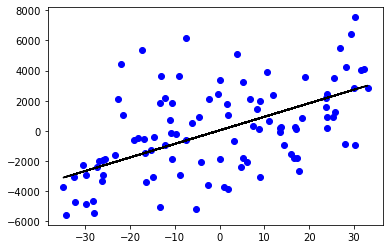

R^2 Value:  0.3277101822343307


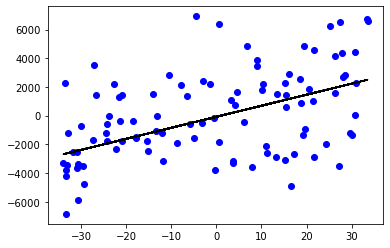

R^2 Value:  0.23846906613013685


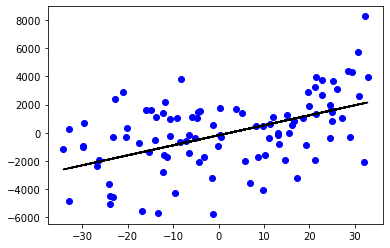

R^2 Value:  0.22262794567828115


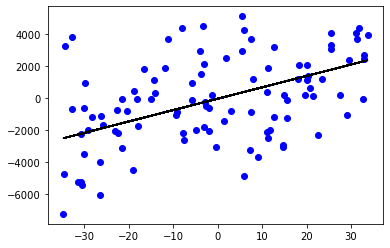

R^2 Value:  0.23925963186246368


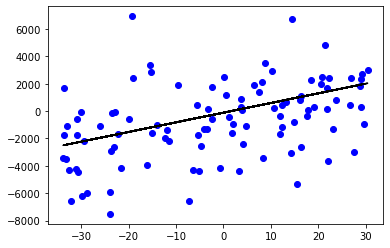

R^2 Value:  0.21861913773554298


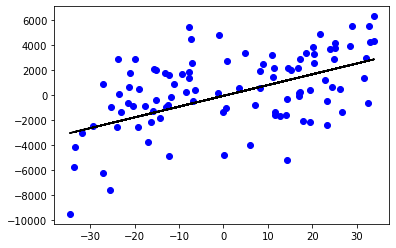

R^2 Value:  0.316717517305418


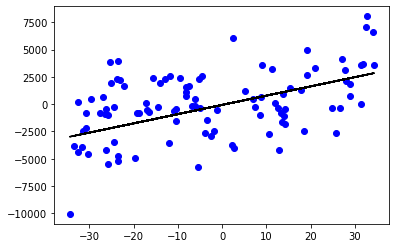

R^2 Value:  0.24659967293410445


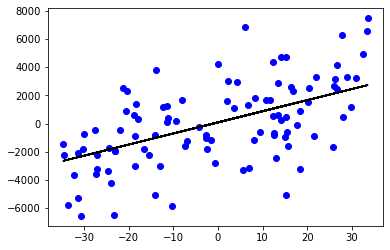

R^2 Value:  0.2874718138859771


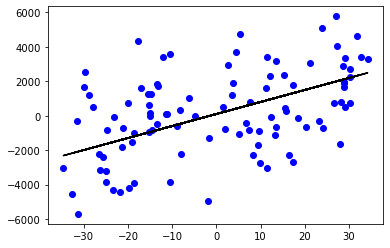

R^2 Value:  0.2195667433013836


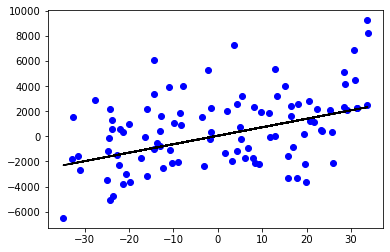

R^2 Value:  0.22636586469175735


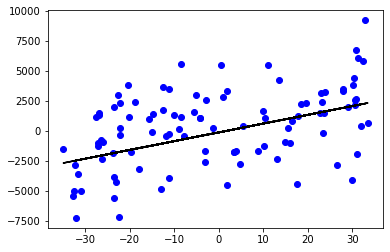

R^2 Value:  0.24629016671265247


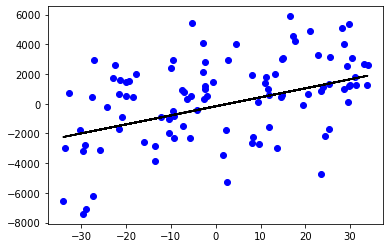

R^2 Value:  0.17004683737315285


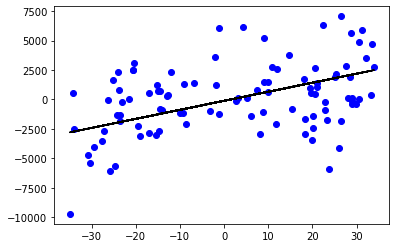

R^2 Value:  0.22466561846336008


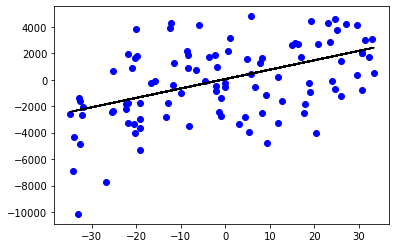

R^2 Value:  0.20266278986930097


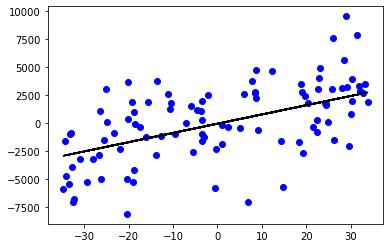

R^2 Value:  0.2996848194265699


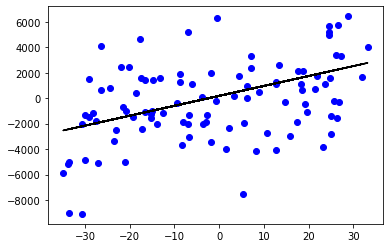

R^2 Value:  0.23964799322156494


In [125]:
for train_set in train_sets:
    # Separate the feature(s) and labels
    X = train_set[:, 0]
    y = train_set[:, 1]
    
    # Convert 1d array to 2d array (train_test_split requires X to be 2 dimensional)
    X = np.reshape(X, (len(X), 1))
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    model = linreg.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Plot graph
    plt.scatter(X_test, y_test, color='blue')
    plt.plot(X_test, predictions, color='black')
    plt.show()
    
    # Accuracy of the model
    print("R^2 Value: ", linreg.score(X, y))